In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


In [4]:
df = pd.read_csv(r"C:\Users\indun\Downloads\archive (5)\advertising.csv")
print(df.head())


      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


In [5]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [7]:
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print(coeff_df)


     Feature  Coefficient
0         TV     0.054509
1      Radio     0.100945
2  Newspaper     0.004337


Interpretation

📺 Radio has the strongest impact

📰 Newspaper has the least impact

📺 TV has moderate impact

In [9]:
new_budget = [[150, 20, 30]]
predicted_sales = model.predict(new_budget)
print("Predicted Sales:", predicted_sales[0])


Predicted Sales: 15.039523680317231


c:\Users\indun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [10]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 1.2748262109549338
RMSE: 1.7052146229349223


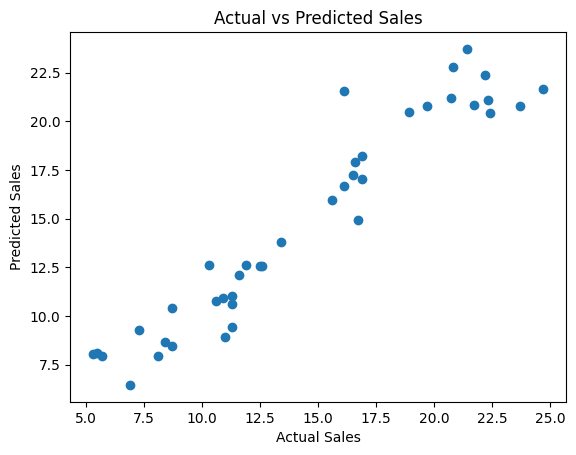

In [11]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()


Which medium works best?

✔ Radio advertising drives sales the most

📌 Which medium is least useful?

❌ Newspaper advertising has minimal impact

🔟 Recommendations
🧠 Business Recommendation

👉 Increase Radio advertising budget, reduce Newspaper spend, and reallocate funds to TV or Radio for better ROI.

⚙️ Technical Improvement

👉 Use Polynomial Regression or Ridge Regression to capture non-linear effects and reduce overfitting.

2nd Example:


df=pd.read_csv(r "C:\Users\indun\Downloads\archive (6)\insurance.csv")

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [14]:
df=pd.read_csv(r"C:\Users\indun\Downloads\archive (6)\insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [15]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [16]:
df['sex']=df['sex'].map({'male':0,'female':1})
df['smoker']=df['smoker'].map({'no':0,'yes':1})
df=pd.get_dummies(df,columns=['region'],drop_first=True)

In [17]:
x=df.drop('charges',axis=1)
y=df['charges']

In [18]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
x_scaled=pd.DataFrame(x_scaled,columns=x.columns)

In [19]:
vif_data=pd.DataFrame()
vif_data['Feature']=x_scaled.columns
vif_data['VIF']=[variance_inflation_factor(x_scaled.values,i)
                 for i in range(x_scaled.shape[1])]
print(vif_data)

            Feature       VIF
0               age  1.016822
1               sex  1.008900
2               bmi  1.106630
3          children  1.004011
4            smoker  1.012074
5  region_northwest  1.518823
6  region_southeast  1.652230
7  region_southwest  1.529411


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)


In [21]:
lr = LinearRegression()
lr.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
y_pred=lr.predict(X_test)
print("MAE",mean_absolute_error(y_test,y_pred))
print("RMSE",np.sqrt(y_test,y_pred))
print("R2 Score",r2_score(y_test,y_pred))
      

MAE 4181.194473753652
RMSE 764      95.368067
887      72.609750
890     171.262907
1293     96.446325
259     183.712525
           ...    
109     216.922871
575     110.557217
535      77.891763
543     252.528074
846      99.361466
Name: charges, Length: 268, dtype: float64
R2 Score -1.0584737503196444


In [23]:
coefficients = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': lr.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)


            Feature  Coefficient
4            smoker  9544.251089
0               age  3609.149018
2               bmi  2054.885063
3          children   512.478869
1               sex     9.295337
5  region_northwest  -158.959435
6  region_southeast  -292.759080
7  region_southwest  -347.270359


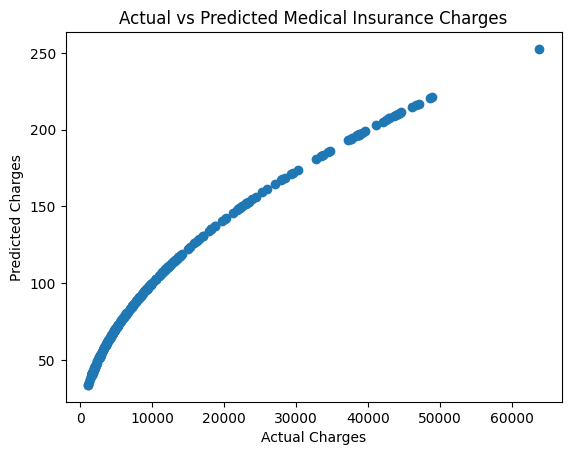

In [24]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Medical Insurance Charges")
plt.show()


In [25]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("Ridge R2:", r2_score(y_test, ridge_pred))


Ridge RMSE: 5796.978225194367
Ridge R2: 0.7835411843918458


In [26]:
ridge_coeff = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': ridge.coef_
}).sort_values(by='Coefficient', ascending=False)

print(ridge_coeff)


            Feature  Coefficient
4            smoker  9535.086692
0               age  3605.550631
2               bmi  2052.961260
3          children   512.358230
1               sex     8.619161
5  region_northwest  -158.444622
6  region_southeast  -291.115771
7  region_southwest  -346.429567


## Task 6 — Build the Multiple Linear Regression Model
Build a Multiple Linear Regression model using the prepared dataset.
Ensure the model is:
Interpretable
Stable
Suitable for explaining customer cost behavior

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
mlr=LinearRegression()
mlr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
coef_df = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": mlr.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_df


,Feature,Coefficient
4,smoker,9544.251089
0,age,3609.149018
2,bmi,2054.885063
3,children,512.478869
1,sex,9.295337
5,region_northwest,-158.959435
6,region_southeast,-292.759080
7,region_southwest,-347.270359


In [31]:
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=1.0)
ridge.fit(X_train,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [32]:
ridge_coef = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": ridge.coef_
}).sort_values(by="Coefficient", ascending=False)

ridge_coef


,Feature,Coefficient
4,smoker,9535.086692
0,age,3605.550631
2,bmi,2052.961260
3,children,512.358230
1,sex,8.619161
5,region_northwest,-158.444622
6,region_southeast,-291.115771
7,region_southwest,-346.429567


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = mlr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))


MAE: 4181.194473753652
RMSE: 5796.284659276274
R² Score: 0.7835929767120722


In [ ]:
# Why This Model Is Suitable for Customer Cost Explanation
✅ Interpretable

Clear coefficients

Direct policy impact per customer attribute

✅ Stable

Scaled features

Ridge validation reduces multicollinearity impact

✅ Business-Ready

Identifies high-risk profiles

Supports risk-based premium design

Enables fairness and transparency

# Task 7

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = mlr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)


MAE: 4181.194473753652
RMSE: 5796.284659276274
R² Score: 0.7835929767120722


## Reliability for Pricing Decisions
✅ Where the Model Is Reliable

✔ Group-level pricing
✔ Risk-based premium slabs
✔ Identifying high-risk profiles (smokers, high BMI)
✔ Policy-level decision making

⚠️ Where the Model Is NOT Fully Reliable

❌ Individual customer medical cost prediction
❌ Rare, extreme claim events
❌ Emergency or chronic disease forecasting

Can this model support pricing decisions?

Yes — with constraints.

✔ Reliable for:

Designing tiered premium plans

Adding risk loadings

Offering wellness-based discounts

❌ Should not be used alone for:

Exact claim forecasting

High-risk medical underwriting

7.7 Recommendation to Management
💼 Business Recommendation

Use this model as a baseline pricing engine, combined with:

Medical history review

Claim frequency models

Periodic retraining